# Evaluation Script: WebViews Explored

This script produces results for Section 5.3 WebViews Explored

### Connect to the MongoDB

In [ ]:
import tqdm
import pymongo

import pandas as pd

client = pymongo.MongoClient("mongodb://localhost:27017/")

db = client["webview"]

bytecode_info_collection = db["bytecode_info"]
dynamic_api_calls_collection = db["dynamic_api_calls"]
webviews_collection = db["webviews"]
unique_webviews_collection = db["unique_webviews"]
library_collection = db["library"]


TOTAL_APPS_DOWNLOADED = 189779
APPS_DYNAMIC_SUCCESS = 34200

def print_latex_macro(name: str, value: str):
    print(f"\\newcommand{{\\{name}}}{{{value}}}")

### Get stats on apps statically and dynamically using WebView APIs

Results for "WebViews Explored"

In [4]:
# Get apps statically using WebView APIs
bytecode_analysis_success_amount = len(bytecode_info_collection.distinct("package_name")) # amount of apps where analysis was successful

webview_package_names = bytecode_info_collection.distinct("package_name", {
    "webViewRelatedMethods.0": {"$exists": True}
})

print_latex_macro("appsStaticallyUsingWebViewAPIs", f"{len(webview_package_names):,}")
print_latex_macro("appsStaticallyUsingWebViewAPIsPercentage", f"{len(webview_package_names) / bytecode_analysis_success_amount * 100:.2f}")


# Get apps dynamically using WebView APIs
amount_apps_dynamically_using_webview = len(dynamic_api_calls_collection.distinct(
    "source_package_name"
))
print_latex_macro("appsDynamicallyUsingWebViewAPIs", f"{amount_apps_dynamically_using_webview:,}")
print_latex_macro("appsDynamicallyUsingWebViewAPIsPercentage", f"{(amount_apps_dynamically_using_webview/APPS_DYNAMIC_SUCCESS)*100:.2f}")


# Get apps dynamically using WebView Instances
package_names_using_webview_instance = []
results = dynamic_api_calls_collection.distinct("source_package_name")
for r in tqdm.tqdm(results):
    # We exclude suport-lib 
    distinct_ids = dynamic_api_calls_collection.find({"source_package_name": r, "webview_id": {"$ne": "support-libnull"}}).distinct("webview_id")
    if len(list(distinct_ids)) > 0:
        package_names_using_webview_instance.append(r)

print_latex_macro("appsDynamicallyUsingWebViewInstances", f"{len(package_names_using_webview_instance):,}")
print_latex_macro("appsDynamicallyUsingWebViewInstancesPercentage", f"{(len(package_names_using_webview_instance)/APPS_DYNAMIC_SUCCESS)*100:.2f}")


\newcommand{\appsStaticallyUsingWebViewAPIs}{183,017}
\newcommand{\appsStaticallyUsingWebViewAPIsPercentage}{97.31}
\newcommand{\appsDynamicallyUsingWebViewAPIs}{25,186}
\newcommand{\appsDynamicallyUsingWebViewAPIsPercentage}{73.64}


100%|██████████| 25186/25186 [14:17<00:00, 29.38it/s]  

\newcommand{\appsDynamicallyUsingWebViewInstances}{23,237}
\newcommand{\appsDynamicallyUsingWebViewInstancesPercentage}{67.94}


## Aggregate all webviews into a 'webview' collection

In [ ]:
pipeline = [
        {
            "$match": {
                "webview_id": {
                "$exists": True,
                # and does not start with support-lib
                "$not": {"$regex": "^support-lib"}
            }
            }
        },
        {
            "$group": {
                "_id": {
                    "webview_id": "$webview_id",
                    "source_package_name": "$source_package_name"
                },
                "source": {"$addToSet": {"$arrayElemAt": ["$trace", 0]}}
            }
        },
        {
            "$project": {
                "_id": 0,
                "webview_id": "$_id.webview_id",
                "source_package_name": "$_id.source_package_name",
                "source": 1
            }
        },
        {
            "$out": "webviews"
        }
]
dynamic_api_calls_collection.aggregate(pipeline, allowDiskUse=True)
    
webviews_collection.create_index("webview_id")
webviews_collection.create_index("source_package_name")
total_amount = webviews_collection.count_documents({})

--- AGGREGATING WEBVIEWS ---
# Aggregated webviews into 'webviews' collection.


#### Adding libraries to webviews

In [ ]:
lib_cache = {}

def get_library_for_class_package(class_name):
    # get all library identifiers 
    if "library_identifiers" in lib_cache:
        library_identifiers = lib_cache["library_identifiers"]
    else:
        library_identifiers = list(library_collection.find({}, {"identifier": 1, "_id": 0}))
        lib_cache["library_identifiers"] = library_identifiers
    matching_identifiers = [lib["identifier"] for lib in library_identifiers if class_name.startswith(lib["identifier"] + ".")]
    if not matching_identifiers:
        return None
        
        # get the longest matching identifier
    matching_identifiers = sorted(matching_identifiers, key=lambda x: len(x), reverse=True)
    longest_matching_identifier = matching_identifiers[0]
    # query the library mapping collection for the longest matching identifier and the package name
    return longest_matching_identifier



for doc in tqdm.tqdm(webviews_collection.find({}), total=webviews_collection.count_documents({}), desc="Classifying libraries for WebViews"):
    package_name = doc["source_package_name"]
    if doc["webview_id"] == -2:
        continue
        
    sources = doc["source"]
    libs = []
    for source in sources:
        if source == None:
            continue
        if source.lower().startswith(package_name.lower()):
            libs.append("*1st-party")
        else:
            library = get_library_for_class_package(source)
            if library and library != "android" and library != "com.android":
                libs.append(library)
        
    # get the item in libs that appears most often
    # exclude some from 'libs'
    libs = [lib for lib in libs if not lib.startswith("androidx.compose") and not lib.startswith("androidx.activity")]

    most_common_lib = None
    if len(libs) > 0:
        most_common_lib = max(set(libs), key=libs.count)
    else:
        most_common_lib = "*unknown-library"

    webviews_collection.update_one(
        {"webview_id": doc["webview_id"], "source_package_name": package_name},
        {"$set": {"libraries": list(set(libs)), "library": most_common_lib}}  
    )

Classifying libraries for WebViews: 100%|██████████| 658894/658894 [43:21<00:00, 253.28it/s]  


#### Create Figure

Produces Figure 3

658894it [00:06, 97633.17it/s] 


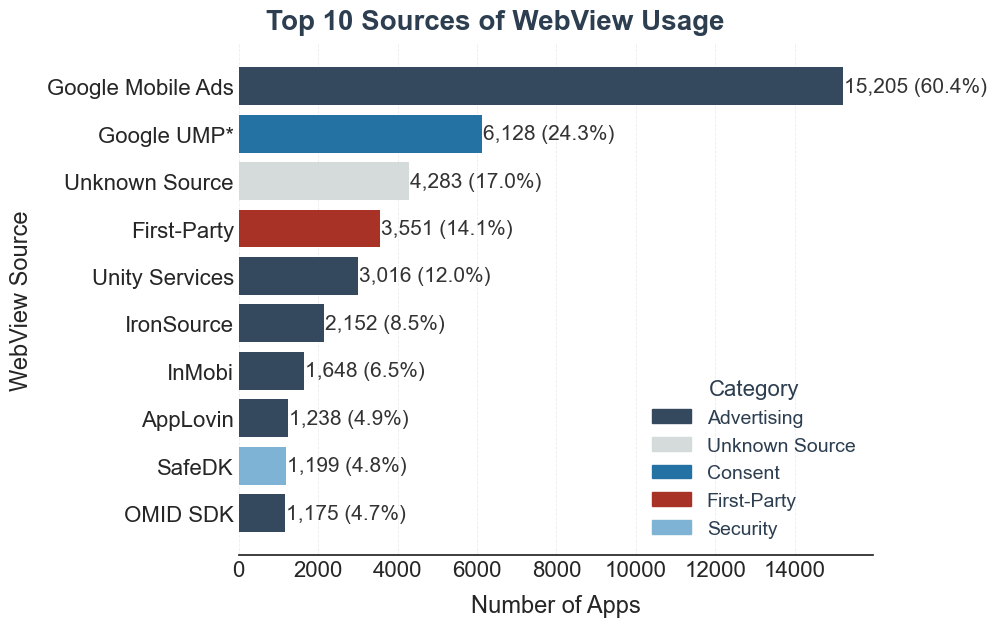

In [12]:
library_apps = {}

results = webviews_collection.find({})
for r in tqdm.tqdm(results):
    package_name = r["source_package_name"]
    libraries = r["libraries"]
    libraries = [lib for lib in libraries if lib != "java"]
    if len(libraries) == 0:
        libraries = ["*unknown-library"]
    for library in libraries:
        if library not in library_apps:
            library_apps[library] = []
        library_apps[library].append(package_name)

lib_apps = []

for library, apps in library_apps.items():
    lib_apps.append((library, len(set(apps))))
    
    
def get_library_info(library_name: str):
        return library_collection.find_one({"identifier": library_name})
    
def get_library_name_category(library):
    category = "Unknown Source"
    name = "Unknown Source"

    if library == "*unknown-library":
        return ("Unknown Source", "Unknown Source")

    lib_info = get_library_info(library)
    if lib_info != None:
        category = lib_info.get("category", "Unknown")
        name = lib_info.get("name", "Unknown")
    if library == "*1st-party" and lib_info == None:
        return ("First-Party", "First-Party")
    elif lib_info == None:
        return ("Unknown", "Unknown")
    return (name, category)

# list of tuples to dataframe
lib_apps_df = pd.DataFrame(lib_apps, columns=["library", "app_count"])
lib_apps_df["library_name"] = lib_apps_df["library"].apply(lambda x: get_library_name_category(x)[0])
lib_apps_df["library_category"] = lib_apps_df["library"].apply(lambda x: get_library_name_category(x)[1])
lib_apps_df["app_percentage"] = lib_apps_df["app_count"] / len(apps)


academic_palette = {
    "UI<br>Comp-<br>onents": "#7FB3D5",  # Darkest Teal
    "UI Components": "#7FB3D5",  # Darkest Teal
    "Advertising": "#34495e",    # Deep Teal
    "unknown": "#D5DBDB",        # Slate Gray (Neutral)
    "Unknown": "#D5DBDB", 
    "Unknown Source": "#D5DBDB",
    "Consent": "#2471A3",
    "First-Party": "#A93226",
    "first-party": "#A93226",
    "Other Categories": "#D98880",
    "Other Libraries": "#BDC3C7",
    "Utility": "#BDC3C7",
    "Security": "#7FB3D5",
    "Development Environment": "#7FB3D5"
}


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# --- 1. Aesthetic Configuration ---
plt.style.use('seaborn-v0_8-white')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#2c3e50'
plt.rcParams['axes.labelsize'] = 16 
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

# --- 2. Data Preparation ---
# Filter and sort
top_10_df = lib_apps_df[lib_apps_df['library'] != 'java.lang.reflect']
top_10_df = top_10_df.sort_values(by='app_count', ascending=False).head(10)
top_10_df = top_10_df.sort_values(by='app_count', ascending=True)

# Clean names
top_10_df['library_name'] = top_10_df['library_name'].apply(
    lambda x: 'Google UMP*' if x == 'Google User Messaging Platform' else x
)

top_10_df['library_name'] = top_10_df['library_name'].apply(
    lambda x: 'First-Party' if x == 'first-party' else x
)

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(10, 7))

# Colors based on category
bar_colors = [academic_palette[cat] for cat in top_10_df['library_category']]

# Horizontal Grid
ax.grid(axis='x', linestyle='--', linewidth=0.6, color='#e0e0e0', alpha=0.6, zorder=0)

bars = ax.barh(top_10_df['library_name'], top_10_df['app_count'], color=bar_colors, zorder=3)

# Bar Labels (Count + Percentage)
for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, 
            bar.get_y() + bar.get_height()/2, 
            f'{int(width):,} ({width / amount_apps_dynamically_using_webview:.1%})',
            va='center', ha='left', fontsize=15, color='#333333', fontfamily='Arial')

# --- 4. Title and Labels ---
# decrease the padding of the subtitle
fig.suptitle('Top 10 Sources of WebView Usage', fontsize=20, weight='bold', fontfamily='Arial', y=0.92)

ax.set_xlabel('Number of Apps', fontsize=17, labelpad=10)
ax.set_ylabel('WebView Source', fontsize=17, labelpad=10)

# --- 5. Legend and Note ---
sns.despine(ax=ax, left=True, bottom=False)

legend_handles = [mpatches.Patch(color=color, label=cat) 
                  for cat, color in academic_palette.items() 
                  if cat in top_10_df['library_category'].values]

ax.legend(handles=legend_handles, loc='lower right', frameon=False, 
          fontsize=14, title="Category", title_fontsize=16)

# Adjust layout to make room for title and footnote
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
#plt.show()
# save the plot as a pdf
plt.savefig('top_10_webview_usage.pdf', dpi=300, bbox_inches='tight')

In [26]:
# merge WebViews
import json
KEY_APIS = {
    "SET_WEBVIEW_CLIENT": [0],
    "ADD_JAVASCRIPT_INTERFACE": [0, 1],
    "SET_WEBCHROME_CLIENT": [0],
    "WEB_SETTINGS_SET_JAVA_SCRIPT_ENABLED": [0],
    "WEB_SETTINGS_SET_ALLOW_CONTENT_ACCESS": [0],
    "WEB_SETTINGS_SET_ALLOW_FILE_ACCESS": [0],
    "WEB_SETTINGS_SET_ALLOW_FILE_ACCESS_FROM_FILE_URLS": [0],
    "WEB_SETTINGS_SET_ALLOW_UNIVERSAL_ACCESS_FROM_FILE_URLS": [0],
    "LOAD_URL": [],
    "LOAD_DATA": [],
    "LOAD_DATA_WITH_BASE_URL": [0],
    "POST_URL": [],
    "EVALUATE_JAVASCRIPT": []
}

def build_signature(documents):
    webview_id = documents[0].get("webview_id", "unknown")
    package_name = documents[0].get("source_package_name", "unknown")
    state = {api: [] for api in KEY_APIS}
    for doc in sorted(documents, key=lambda d: d.get("timestamp", 0)):
        api = doc.get("api")
        
        if api in KEY_APIS:
            params = doc.get("params", [])
            if len(state[api]) > 0:
                # We only take the first call of each API in consideration, as it can happen that APIs are called multiple times but the UI automator breaks the app
                #pass
                continue
            
                   
            vals = [params[i] if i < len(params) else None for i in KEY_APIS[api]]
            new_params = []
            for p in vals:
                if api == "SET_WEBVIEW_CLIENT" or api == "SET_WEBCHROME_CLIENT" or api == "ADD_JAVASCRIPT_INTERFACE":
                    # remove any @ suffixes from class names
                    if p != None:
                        p = p.split("@")[0]
                    new_params.append(str(p))
                else:
                    new_params.append(str(p))
            
            trace = doc.get("trace", [])[:3]
            new_trace = []
            for t in trace:
                t = t.split("@")[0]
                new_trace.append(t)
            
            
            state[api].append({
                "params": "|".join(new_params),
                "trace": new_trace
            })
        
    #print(f"# Built signature for {webview_id} and package {package_name}: ")
    # serialize the state
    serialized_state = json.dumps(state)
    return serialized_state
    
    
    

mapping = {}
none = 0
# get package names from webviews
package_names = webviews_collection.distinct("source_package_name")
for package_name in tqdm.tqdm(package_names):
    keys = []
    for webview in webviews_collection.find({"source_package_name": package_name}):
        webview_id = webview["webview_id"]
        package_name = webview["source_package_name"]        
        api_calls = dynamic_api_calls_collection.find({
            "webview_id": webview_id,
            "source_package_name": package_name,
            "api": {"$in": list(KEY_APIS.keys())}
        })
        api_calls = list(api_calls)
        if (len(api_calls) == 0):
            none += 1
            keys.append((webview_id, "none"))
        else:
            #print(f"Building signature for WebView ID {webview_id} in package {package_name}")
            #print(api_calls)
            key = build_signature(api_calls)
            keys.append((webview_id, key))
            
    # get the webview_ids for which the key is the same
    signature_mapping = {}
    for webview_id, key in keys:
        if key not in signature_mapping:
            signature_mapping[key] = []
        signature_mapping[key].append(webview_id)
    #print(f"# Package {package_name} has {len(signature_mapping)} unique WebView signatures.")
    for key, webview_ids in signature_mapping.items():
        # get all webview items with webview_id in webview_ids
        wvs = webviews_collection.find({"webview_id": {"$in": webview_ids}})
        primary_libs = set([wv.get("library", "??") for wv in wvs])
        
        # filter out None from primary_libs
        primary_libs = [lib for lib in primary_libs if lib != None]
        # if there is no lib in primary libs,
        #if (len(primary_libs) == 0):
        #    print("THIS SHOULD NOT HAPPEN")

        primary_libs = [lib for lib in primary_libs if lib != "*unknown-library"]

        if len(primary_libs) == 0:
            primary_libs = ["*unknown-library"]

        #if (len(primary_libs) > 1):
        #    print(f"Package {package_name} has multiple primary libraries: {primary_libs}")
        
        unique_webviews_collection.insert_one({
            "package_name": package_name,
            "webview_ids": webview_ids,
            "signature": key,
            "primary_library": primary_libs.pop() if len(primary_libs) == 1 else "multiple"
        })


100%|██████████| 23237/23237 [42:04<00:00,  9.20it/s]  


### Unique WebViews

Produces results for "Unique WebViews"

In [27]:
unique_webviews = unique_webviews_collection.count_documents({})
apps_unique_webviews = unique_webviews_collection.distinct("package_name", {})
print("Apps with unique webviews:", len(apps_unique_webviews))

dynamic_package_names_results_available = []

analysis_succeeded_amount = 34200

print_latex_macro("uniqueWebViews", f"{unique_webviews:,}")
print_latex_macro("averageWebViewsPerApp", f"{unique_webviews / analysis_succeeded_amount:.2f}")


package_names_using_webview = dynamic_api_calls_collection.distinct(
    "source_package_name"
)
webviews_per_app = []
for package_name in package_names_using_webview:
    webviews_count = unique_webviews_collection.count_documents({
        "package_name": package_name
    })
    webviews_per_app.append(webviews_count)
    
import numpy as np
median_webviews_per_app = np.median(webviews_per_app)
print_latex_macro("medianWebViewsPerApp", f"{median_webviews_per_app:.2f}")

Apps with unique webviews: 23237
\newcommand{\uniqueWebViews}{177,187}
\newcommand{\averageWebViewsPerApp}{5.18}
\newcommand{\medianWebViewsPerApp}{4.00}


#### Get the Origins of WebViews

Produces results in "Origins of WebViews"

In [28]:
total_amount_unique_webviews = unique_webviews_collection.count_documents({})
print(total_amount_unique_webviews)
amount_first_party_webviews = unique_webviews_collection.count_documents({"primary_library": "*1st-party"})

print_latex_macro("amountFirstPartyWebViews", f"{amount_first_party_webviews}")
print_latex_macro("amountFirstPartyWebViewsPercentage", f"{amount_first_party_webviews / total_amount_unique_webviews*100:.2f}")

amount_webviews = webviews_collection.count_documents({})

amount_shared_libs = 0
packages_multiple_libs = {}
webviews_with_shared_libraries = webviews_collection.find({"libraries.1": {"$exists": True}})
for wv in webviews_with_shared_libraries:
    libs = wv.get("libraries", [])
    package_name = wv.get("source_package_name", "")
    # filter out anything starting with "com.android"
    libs = [lib for lib in libs if not lib.startswith("com.android")]
    libs = [lib for lib in libs if not lib.startswith("com.androidx")]
    libs = [lib for lib in libs if not lib.startswith("java.lang.reflect")]
    if (len(libs) > 1):
        amount_shared_libs += 1
        libs = tuple(libs)
        if libs not in packages_multiple_libs: 
            packages_multiple_libs[libs] = []
        packages_multiple_libs[libs].append(package_name)

amount_webviews_with_shared_libraries = amount_shared_libs


#print_latex_macro("amountWebViews", f"{amount_webviews}")
#print_latex_macro("amountWebViewsWithSharedLibraries", f"{amount_webviews_with_shared_libraries}")
print_latex_macro("amountWebViewsWithSharedLibrariesPercentage", f"{amount_webviews_with_shared_libraries / amount_webviews*100:.2f}")

# print the most common library combinations
print()
print("Most common libraries where WebViews are shared:")
for libs, packages in sorted(packages_multiple_libs.items(), key=lambda item: len(item[1]), reverse=True):
    print(f"{len(packages)}: {libs} ({len(packages)})")

177187
\newcommand{\amountFirstPartyWebViews}{6130}
\newcommand{\amountFirstPartyWebViewsPercentage}{3.46}
\newcommand{\amountWebViewsWithSharedLibrariesPercentage}{6.98}

Most common libraries where WebViews are shared:
5462: ('com.google.android.gms.internal.consent_sdk', 'com.safedk.android') (5462)
4337: ('com.ironsource', 'com.safedk.android') (4337)
4199: ('com.unity3d', 'com.safedk.android') (4199)
2634: ('com.applovin', 'com.safedk.android') (2634)
2217: ('com.mbridge', 'com.safedk.android') (2217)
2117: ('com.fyber', 'com.iab.omid') (2117)
1900: ('com.ironsource', 'com.google.android.gms.ads') (1900)
1724: ('com.facebook', 'com.reactnativecommunity.webview') (1724)
1417: ('org.apache', 'com.ionicframework.cordova.webview') (1417)
1148: ('com.fyber', 'com.safedk.android') (1148)
766: ('p.haeg.w', 'com.google.android.gms.ads') (766)
707: ('com.google.android.gms.internal.ads', 'com.google.android.gms.ads') (707)
651: ('io', 'com.iab.omid') (651)
574: ('androidx.webkit', 'com.pic

## Get the unique WebViews